# Create a pixel-table exposure for fl16y

In [25]:
%reset -f
%run pylib/tools dark date
from pylib import pixel_table; reload(pixel_table)
from pylib.pixel_table import *
from like3.exposure import EffectiveAreaIRF
pixel_table = PixelTable('files/kerr/toby_v4.fits')

<h5 style="text-align:right; margin-right:15px"> 2026-04-01 03:35</h5>

Loaded pixel table from "files/kerr/toby_v4.fits":
            43 bands Band(0, 4): PSF0@1.33 GeV nside 64 occ 1.000 ... Band(3, 11): PSF3@74.99 GeV nside 2048 occ 0.000
            206,555,017 photons
            8,241,643 pixels
            


In [26]:
from pathlib import Path
from astropy.io import fits
import numpy as np
from like3.exposure import EffectiveAreaIRF, make_exposure_map_healpix

livetime_file = Path('files/livetime_fl16y_nside128.fits')
if not livetime_file.exists():
    raise FileNotFoundError(livetime_file)

with fits.open(livetime_file) as hdul:
    hdu = hdul[1] if len(hdul) > 1 else hdul[0]
    data = np.asarray(hdu.data)
    if data.dtype.names:
        col = 'LIVETIME' if 'LIVETIME' in data.dtype.names else data.dtype.names[0]
        livetime_map = np.asarray(data[col], dtype=float).ravel()
    else:
        livetime_map = np.asarray(data, dtype=float).ravel()

aeff_psf3 = EffectiveAreaIRF(
    irf='P8R3_SOURCE_V3',
    file_path='/home/burnett/wtlike-data/aeff_files',
    partition='PSF3',
)

exposure_map_psf3_100_215 = make_exposure_map_healpix(
    Aeff=aeff_psf3,
    emin=100.0,
    emax=215.4,
    livetime=livetime_map,
    nside=128,
    event_type=5,
    n_energy=32,
)

print('Exposure map shape:', exposure_map_psf3_100_215.shape)
print('min/max:', float(np.min(exposure_map_psf3_100_215)), float(np.max(exposure_map_psf3_100_215)))

Exposure map shape: (196608,)
min/max: 76011913216.0 215083368448.0


In [27]:
import importlib
import sys

sys.modules.pop('like3.exposure', None)
sys.modules.pop('pylib.pixel_table', None)

import like3.exposure as exposure_mod
import pylib.pixel_table as pixel_table_mod

exposure_mod = importlib.reload(exposure_mod)
pixel_table_mod = importlib.reload(pixel_table_mod)

pixel_table = pixel_table_mod.PixelTable.from_fits('files/kerr/toby_v4.fits')
pixel_table.build_exposure(
    livetime_map,
    file_path='/home/burnett/wtlike-data/aeff_files',
    irf='P8R3_SOURCE_V3',
    n_energy=32,
)

pixel_table.meta_df[['event_type', 'emin', 'emax', 'exposure']].head(), pixel_table.pixel_exposure_df.head()

Loaded pixel table from "files/kerr/toby_v4.fits":
            43 bands Band(0, 4): PSF0@1.33 GeV nside 64 occ 1.000 ... Band(3, 11): PSF3@74.99 GeV nside 2048 occ 0.000
            206,555,017 photons
            8,241,643 pixels
            


(  event_type          emin          emax      exposure
 0       PSF0   1000.000000   1778.279410  2.556796e+11
 1       PSF0   1778.279410   3162.277660  2.820797e+11
 2       PSF0   3162.277660   5623.413252  2.813360e+11
 3       PSF0   5623.413252  10000.000000  2.833483e+11
 4       PSF0  10000.000000  17782.794100  2.948692e+11,
   band_key  pix  pixel_exposure
 0   (0, 4)    0    2.479225e+11
 1   (0, 4)    1    2.500320e+11
 2   (0, 4)    2    2.469931e+11
 3   (0, 4)    3    2.492462e+11
 4   (0, 4)    4    2.518982e+11)

In [18]:
roundtrip_file = Path('files/kerr/toby_v4_exposure.fits')

pixel_table.to_fits(roundtrip_file)
pixel_table_rt = pixel_table_mod.PixelTable.from_fits(roundtrip_file)

print('Round-trip file:', roundtrip_file)
print('Has per-pixel exposure:', hasattr(pixel_table_rt, 'pixel_exposure'))
print('Has per-band exposure column:', 'exposure' in pixel_table_rt.meta_df.columns)

np.testing.assert_allclose(pixel_table_rt.pixel_exposure, pixel_table.pixel_exposure)
np.testing.assert_allclose(
    pixel_table_rt.meta_df['exposure'].to_numpy(),
    pixel_table.meta_df['exposure'].to_numpy(),
)

pixel_table_rt.meta_df[['event_type', 'emin', 'emax', 'exposure']].head(), pixel_table_rt.pixel_exposure_df.head()

wrote file files/kerr/toby_v4_exposure.fits
Loaded pixel table from "files/kerr/toby_v4_exposure.fits":
            43 bands Band(0, 4): PSF0@1.33 GeV nside 64 occ 1.000 ... Band(3, 11): PSF3@74.99 GeV nside 2048 occ 0.000
            206,555,017 photons
            8,241,643 pixels
            
Round-trip file: files/kerr/toby_v4_exposure.fits
Has per-pixel exposure: True
Has per-band exposure column: True


(  event_type          emin          emax      exposure
 0       PSF0   1000.000000   1778.279410  2.556796e+11
 1       PSF0   1778.279410   3162.277660  2.820797e+11
 2       PSF0   3162.277660   5623.413252  2.813360e+11
 3       PSF0   5623.413252  10000.000000  2.833483e+11
 4       PSF0  10000.000000  17782.794100  2.948692e+11,
   band_key  pix  pixel_exposure
 0   (0, 4)    0    2.479225e+11
 1   (0, 4)    1    2.500320e+11
 2   (0, 4)    2    2.469931e+11
 3   (0, 4)    3    2.492462e+11
 4   (0, 4)    4    2.518982e+11)

In [28]:
import sys
import importlib
from astropy.coordinates import SkyCoord
import astropy.units as u

sys.modules.pop('like3.exposure', None)
exposure_mod = importlib.import_module('like3.exposure')
expmap_psf3 = exposure_mod.ExposureMap(exposure_map_psf3_100_215, nside=128, frame='icrs')

# Example usage at Crab position (ICRS).
expmap_psf3(SkyCoord(ra=83.6331 * u.deg, dec=22.0145 * u.deg, frame='icrs'))

179559171483.76584

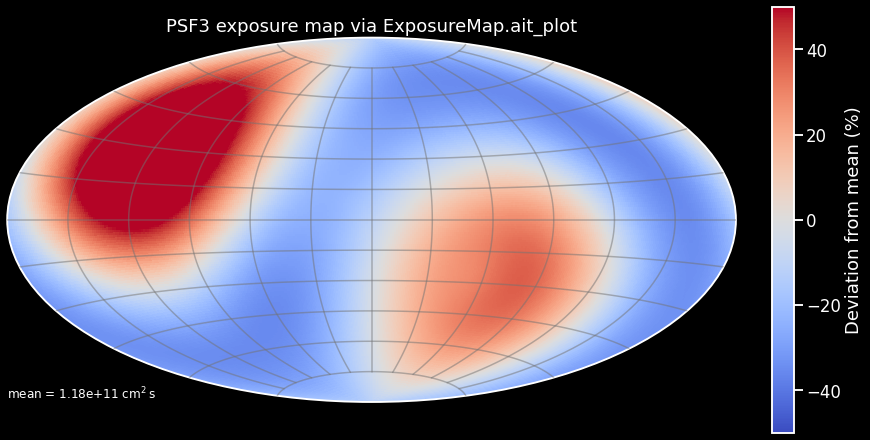

In [24]:
expmap_psf3.ait_plot(
    title='PSF3 exposure map via ExposureMap.ait_plot', vmin=-50, vmax=50
)

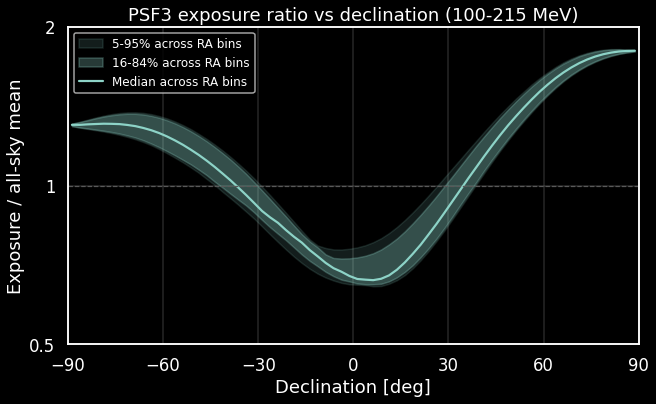

In [62]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FixedFormatter, FixedLocator, NullLocator

values = np.asarray(expmap_psf3.values, dtype=float)
mean_exposure = np.nanmean(values[np.isfinite(values)])
exposure_ratio = values / mean_exposure

hpicrs = HEALPix(nside=128, frame='galactic').healpix_to_skycoord(range(len(values))).icrs
ra = hpicrs.ra.deg 
dec = hpicrs.dec.deg  

dec_edges = np.linspace(-90.0, 90.0, 73)
ra_edges = np.linspace(0.0, 360.0, 25)
dec_centers = 0.5 * (dec_edges[:-1] + dec_edges[1:])

ra_dec_ratio = np.full((len(ra_edges) - 1, len(dec_centers)), np.nan)
finite = np.isfinite(exposure_ratio)

for i, (ra0, ra1) in enumerate(zip(ra_edges[:-1], ra_edges[1:])):
    ra_mask = (ra >= ra0) & (ra < ra1)
    for j, (dec0, dec1) in enumerate(zip(dec_edges[:-1], dec_edges[1:])):
        mask = finite & ra_mask & (dec >= dec0) & (dec < dec1)
        if np.any(mask):
            ra_dec_ratio[i, j] = np.nanmedian(exposure_ratio[mask])

percentiles = np.full((5, len(dec_centers)), np.nan)
for j in range(len(dec_centers)):
    valid = ra_dec_ratio[:, j]
    valid = valid[np.isfinite(valid)]
    if valid.size:
        percentiles[:, j] = np.percentile(valid, [5, 16, 50, 84, 95])

p05, p16, p50, p84, p95 = percentiles

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
ax.fill_between(dec_centers, p05, p95, color='C0', alpha=0.14, label='5-95% across RA bins')
ax.fill_between(dec_centers, p16, p84, color='C0', alpha=0.28, label='16-84% across RA bins')
ax.plot(dec_centers, p50, color='C0', lw=2.2, label='Median across RA bins')
ax.axhline(1.0, color='0.35', lw=1.2, ls='--')
ax.set(
    xlabel='Declination [deg]',
    ylabel='Exposure / all-sky mean',
    ylim=(0.5, 2),
    title='PSF3 exposure ratio vs declination (100-215 MeV)',
    xticks=np.arange(-90, 91, 30), xlim=(-90, 90),
)
ax.set_yscale('log')
ax.yaxis.set_major_locator(FixedLocator([0.5, 1.0, 2.0]))
ax.yaxis.set_major_formatter(FixedFormatter(['0.5', '1', '2']))
ax.yaxis.set_minor_locator(NullLocator())

ax.grid(alpha=0.3, which='major')
ax.legend(loc='best', fontsize=12)

plt.show()